# Кредитный скоринг

## Постановка задачи:
Провести исследовательский анализ данных:
- найти и обработать пропуски
- понять основные характеристики признаков
- обработать неверные значения и выбросы

## 1. Подготовка данных

## 1.1 Общий обзор

In [103]:
#загрузим библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [104]:
#считаем датасет
credit_df = pd.read_csv('train.csv', index_col='ID')

C:\Users\79659\AppData\Local\Temp\ipykernel_10992\1840159357.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_df = pd.read_csv('train.csv', index_col='ID')


In [105]:
#отобразим
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [106]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Name                      90015 non-null   object 
 3   Age                       100000 non-null  object 
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  object 
 7   Monthly_Inhand_Salary     84998 non-null   float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  object 
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  

В датафрейме 26 признаков и 1 целевая переменная.

Проблемы с датафреймом:
1. пропуски в 8 столбцах
2. столбцы, представляющие числовые данные, представлены в виде object.

- 0   ID                         - идентификатор
- 1   Customer_ID               - идентификатор клиента 
-  2   Month                     - месяц 
-  3   Name                      - имя 
- 4   Age                       - возраст 
- 5   SSN                       - номер социального страхования
- 6   Occupation                - род деятельности 
- 7   Annual_Income             - ежегодный доход 
- 8   Monthly_Inhand_Salary     - ежемесячный доход без учета налогов
- 9   Num_Bank_Accounts         - количество банковских аккаунтов
- 10  Num_Credit_Card           - номер кредитной карты
- 11  Interest_Rate             - процентная ставка 
- 12  Num_of_Loan               - количество кредитов 
- 13  Type_of_Loan              - тип кредита 
- 14  Delay_from_due_date       - задержка срока платежа
- 15  Num_of_Delayed_Payment    - количество задержек
- 16  Changed_Credit_Limit      - изменение кредитного лимита
- 17  Num_Credit_Inquiries      - количество запросов кредита
- 18  Credit_Mix                - кредит мик
- 19  Outstanding_Debt          - непогашенный долг
- 20  Credit_Utilization_Ratio  - коэффициент использования кредита
- 21  Credit_History_Age        - протяженности кредитной истории 
- 22  Payment_of_Min_Amount     - минимальный платеж 
- 23  Total_EMI_per_month       - равномерные ежемесячные платежи
- 24  Amount_invested_monthly   - ежемесячные инвестиции 
- 25  Payment_Behaviour         - платежное поведение
- 26  Monthly_Balance           - ежемесячный баланс 
- 27  Credit_Score              - кредитный рейтинг

Посмотрим статистики по разным столбцам в зависимости от типа.

In [107]:
credit_df.select_dtypes(include='number').describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [108]:
credit_df.select_dtypes(include='object').describe()

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


Сразу замечаем, что у столбцов с числовыми значениями тип данных object, есть некорректные значения. Данным необходима перекодировка и очистка.
Рассмотрим каждый столбец отдельно и проведем анализ.


## Анализ признаков

У нас есть две дублирующие друг друга строки Customer-ID и ID. 

In [109]:
print(f'Количество уникальных значений для Customer-ID: {len(credit_df['Customer_ID'].unique())}')
print(f'Количество пропусков для Custome-ID {credit_df['Customer_ID'].isna().sum()}')

Количество уникальных значений для Customer-ID: 12500
Количество пропусков для Custome-ID 0


In [110]:
print(f'Есть ли пропуски в индексе: {credit_df.index.hasnans}')
print(f'Содержатся ли в индексе уникальные значения: {credit_df.index.nunique()}')

Есть ли пропуски в индексе: False
Содержатся ли в индексе уникальные значения: 100000


Датафрейм содержит данные о 12500 клиентах. В качестве индекса используется идентификтор, уникальный для каждой строки. Он не информативен и его можно удалить без потери информации.

In [111]:
#посмотрим, сколько у нас уникальных значений в категории месяц
print(f'уникальный значений в категории месяц: {len(credit_df["Month"].unique())}')
print(*credit_df['Month'].unique(), sep='\n')

уникальный значений в категории месяц: 8
January
February
March
April
May
June
July
August


в датафрейме представленные данные 12500 клиентов за восемь полных месяцев.

In [112]:
#так как часть данных вметсо числовых форматов представлена в object напишем функцию для удаления нечисловых символов из количественных данных
def numeric(x):
    x = list(x)
    for i in x:
        if i in '.1234567890':
            continue
        else:
            x.remove(i)
    return ''.join(x)

In [113]:
#применим функцию numeric к столбцу age
credit_df['Age'] = credit_df['Age'].apply(numeric)
#поменяем тип данных категори возраст на int и посмотрим их распределение
credit_df['Age'] = credit_df['Age'].astype(int)

In [114]:
#проверим работу функции
credit_df['Age']

ID
0x1602      23
0x1603      23
0x1604     500
0x1605      23
0x1606      23
          ... 
0x25fe9     25
0x25fea     25
0x25feb     25
0x25fec     25
0x25fed     25
Name: Age, Length: 100000, dtype: int64

In [115]:
print(f'Количество пропусков в графе возраст {credit_df['Age'].isna().sum()}')

Количество пропусков в графе возраст 0


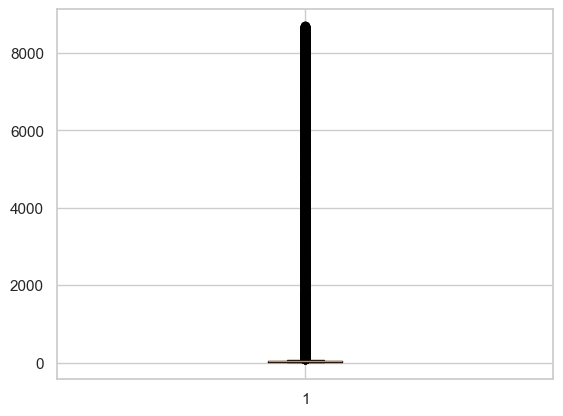

In [116]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [117]:
credit_df['Age'].describe()

count    100000.000000
mean        119.509700
std         684.757313
min          14.000000
25%          25.000000
50%          34.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Статистики и боксплот показывают, что у нас скошенное распределение и большой хвост выбросов. Почистим данные. У нас к одному клиенту относятся сразу несколько строк. Отфитруем строки, возраст в которых находится от 17 до 100, затем объединим их с общим датафрефреймом, заменив возраст у клиента на верный, если он у него есть. 

In [118]:
#отфильтруем возраст клиентов от 17 до 100, чтобы избавится от выбросов
age_df = credit_df[(credit_df['Age'] >= 17) & (credit_df['Age'] <= 100)][['Age', 'Customer_ID']]
age_df 

,Age,Customer_ID
ID,,
0x1602,23,CUS_0xd40
0x1603,23,CUS_0xd40
0x1605,23,CUS_0xd40
0x1606,23,CUS_0xd40
0x1607,23,CUS_0xd40
...,...,...
0x25fe9,25,CUS_0x942c
0x25fea,25,CUS_0x942c
0x25feb,25,CUS_0x942c


In [119]:
#объединяем очищенную таблицу возрастов с датафреймом
credit_df = credit_df.merge(age_df, on='Customer_ID', how='right', suffixes=('', '_correct'))
credit_df = credit_df.drop(columns='Age')
credit_df = credit_df.rename(columns={'Age_correct' : 'Age'})

In [120]:
credit_df

,Customer_ID,Month,Name,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Age
0,CUS_0xd40,January,Aaron Maashoh,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,...,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good,23
1,CUS_0xd40,February,Aaron Maashoh,821-00-0265,Scientist,19114.12,NaN,3,4,3,...,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good,23
2,CUS_0xd40,March,Aaron Maashoh,821-00-0265,Scientist,19114.12,NaN,3,4,3,...,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good,23
3,CUS_0xd40,April,Aaron Maashoh,821-00-0265,Scientist,19114.12,NaN,3,4,3,...,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good,23
4,CUS_0xd40,May,Aaron Maashoh,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,...,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744155,CUS_0x942c,April,Nicks,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,...,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor,25
744156,CUS_0x942c,May,Nicks,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,...,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor,25
744157,CUS_0x942c,June,Nicks,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,...,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor,25
744158,CUS_0x942c,July,Nicks,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,...,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard,25


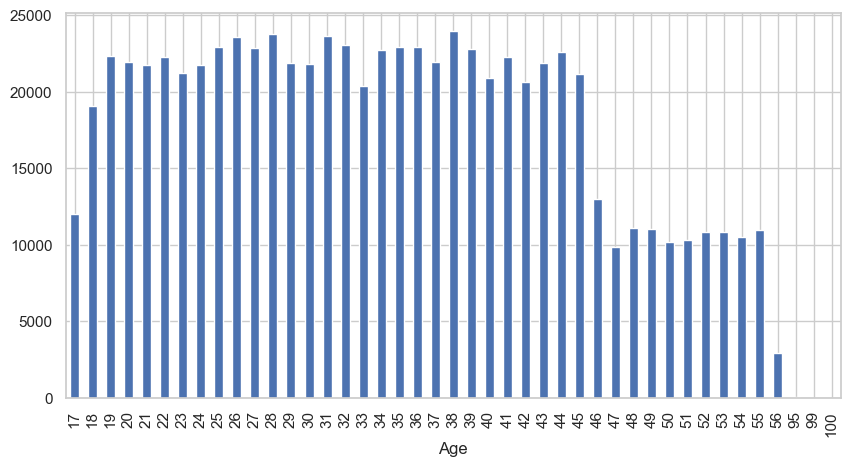

In [121]:
age_group = credit_df.groupby(by='Age')['Age'].count()
age_group.plot(kind='bar', grid=True, figsize=(10, 5))
plt.show()

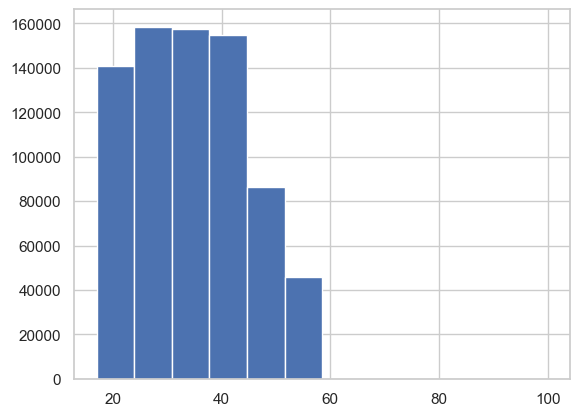

In [122]:
plt.hist(credit_df['Age'], bins=12)
plt.show()
plt.grid()

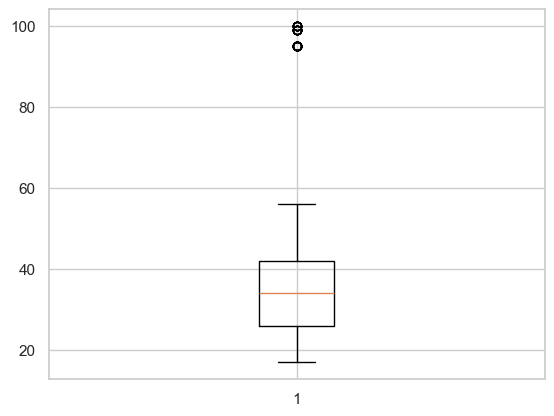

In [134]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [146]:
credit_df.loc[credit_df['Age'] > 80].groupby('Name')[['Annual_Income', 'Age']].mean(numeric_only=True)

,Annual_Income,Age
Name,,
Charlieg,35520.48,99.0
Costas Pitasw,46162.62,95.0
Gerryg,68484.44,95.0
Jim Finkleu,28169.69,95.0
Seetharamanw,30819.56,100.0


В датафрейме присутвуют 6 клиентов с возрастом около ста лет, их мы и видим на графиках и распределениях. Перейдем к анализу дохода.

In [124]:
#Annual Income
credit_df['Annual_Income'] = credit_df['Annual_Income'].apply(numeric)
credit_df['Annual_Income'] = credit_df['Annual_Income'].astype(float)

In [159]:
credit_df['Annual_Income'].describe()

count    7.441600e+05
mean     1.779697e+05
std      1.437107e+06
min      7.006035e+03
25%      1.960331e+04
50%      3.789834e+04
75%      7.358400e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

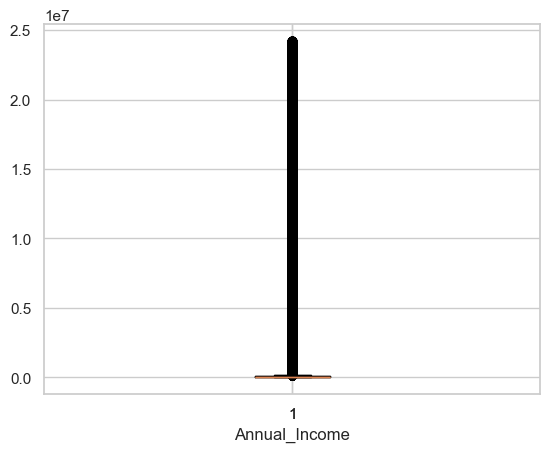

In [158]:
plt.boxplot(x='Annual_Income', data=credit_df)
plt.xlabel('Annual_Income')
plt.show()

In [126]:
#посмотрим ежегодный и ежемесячный доход по профессиям
occupation_annual_income_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary']).round(2).sort_values(by='Annual_Income')

In [127]:
occupation_annual_income_df

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Writer,157694.65,4325.46
Journalist,159865.42,4043.42
Manager,161109.99,4328.41
Teacher,163933.78,4164.06
Architect,169159.49,4305.56
Scientist,172610.70,4328.43
Developer,173686.64,4187.33
_______,175847.88,4201.90
Mechanic,177575.09,4196.34


In [128]:
occupation_annual_income_median_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary'], aggfunc='median').round(2)

In [129]:
#посмотрим медиану
occupation_annual_income_median_df.sort_values(by='Annual_Income', ascending=False)

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Scientist,40807.77,3367.77
Engineer,39700.24,3294.74
Musician,39280.52,3159.11
Manager,39191.16,3255.64
Accountant,39110.82,3229.73
Writer,38858.76,3213.55
Entrepreneur,38577.60,3145.79
Architect,38212.84,3146.42
Media_Manager,37990.27,3156.29


In [130]:
credit_df['Num_Bank_Accounts'].describe()

count    744160.000000
mean         17.235593
std         118.615325
min          -1.000000
25%           3.000000
50%           5.000000
75%           7.000000
max        1798.000000
Name: Num_Bank_Accounts, dtype: float64

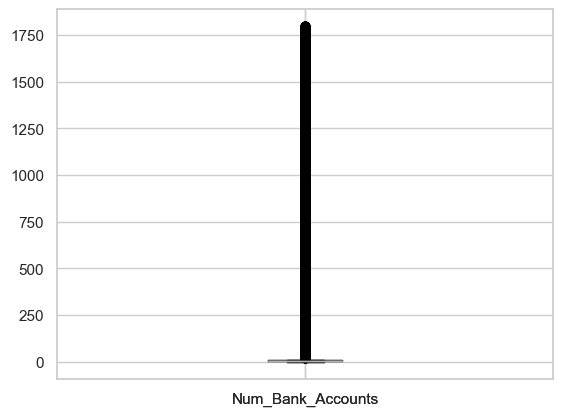

In [148]:
credit_df[['Num_Bank_Accounts']].boxplot()
plt.show()

In [132]:
credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]

,Customer_ID,Month,Name,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Age
2067,CUS_0x4004,April,Carlosj,679-26-6464,Writer,58317.00,NaN,1414,5,9,...,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard,43
2075,CUS_0x4004,April,Carlosj,679-26-6464,Writer,58317.00,NaN,1414,5,9,...,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard,43
2083,CUS_0x4004,April,Carlosj,679-26-6464,Writer,58317.00,NaN,1414,5,9,...,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard,44
2091,CUS_0x4004,April,Carlosj,679-26-6464,Writer,58317.00,NaN,1414,5,9,...,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard,44
2099,CUS_0x4004,April,Carlosj,679-26-6464,Writer,58317.00,NaN,1414,5,9,...,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743516,CUS_0x1619,May,Phil Wahbao,683-59-7399,Media_Manager,20059.98,1523.665,182,5,12,...,909.01,29.808796,NaN,NM,45.076827,49.712993511570424,Low_spent_Medium_value_payments,337.57668,Poor,54
743524,CUS_0x1619,May,Phil Wahbao,683-59-7399,Media_Manager,20059.98,1523.665,182,5,12,...,909.01,29.808796,NaN,NM,45.076827,49.712993511570424,Low_spent_Medium_value_payments,337.57668,Poor,54
743532,CUS_0x1619,May,Phil Wahbao,683-59-7399,Media_Manager,20059.98,1523.665,182,5,12,...,909.01,29.808796,NaN,NM,45.076827,49.712993511570424,Low_spent_Medium_value_payments,337.57668,Poor,54
743540,CUS_0x1619,May,Phil Wahbao,683-59-7399,Media_Manager,20059.98,1523.665,182,5,12,...,909.01,29.808796,NaN,NM,45.076827,49.712993511570424,Low_spent_Medium_value_payments,337.57668,Poor,54


In [160]:
credit_df.loc[credit_df['Num_Bank_Accounts'] < 0]

,Customer_ID,Month,Name,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Age
225178,CUS_0x4f2a,March,Margaretf,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,...,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard,39
225179,CUS_0x4f2a,April,Margaretf,#F%$D@*&8,Engineer,128305.76,NaN,-1,6,1,...,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good,39
225180,CUS_0x4f2a,May,Margaretf,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,...,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good,39
225181,CUS_0x4f2a,June,Margaretf,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,...,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good,39
225182,CUS_0x4f2a,July,Margaretf,807-03-5415,Engineer,128305.76,10434.146667,-1,6,1,...,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413743,CUS_0x5993,August,NaN,120-48-2348,Developer,30352.11,2317.342500,-1,4,7,...,644.57,32.937399,24 Years and 0 Months,No,16.483566,89.62296249058659,High_spent_Medium_value_payments,375.62772128619685,Standard,41
413748,CUS_0x5993,May,Stephensonq,120-48-2348,Developer,30352.11,2317.342500,-1,165,7,...,644.57,25.532001,23 Years and 9 Months,NM,16.483566,126.66534532381421,Low_spent_Medium_value_payments,368.5853384529692,Standard,41
413749,CUS_0x5993,June,NaN,120-48-2348,Developer,30352.11,2317.342500,-1,4,7,...,644.57,31.813259,23 Years and 10 Months,No,16.483566,54.82132668337657,High_spent_Large_value_payments,400.42935709340685,Standard,41
413750,CUS_0x5993,July,Stephensonq,120-48-2348,Developer,30352.11,2317.342500,-1,4,7,...,644.57,26.574175,23 Years and 11 Months,No,16.483566,64.86083753440263,!@9#%8,400.38984624238066,Standard,41
